鍙敤鍙橀噺鏁? 83


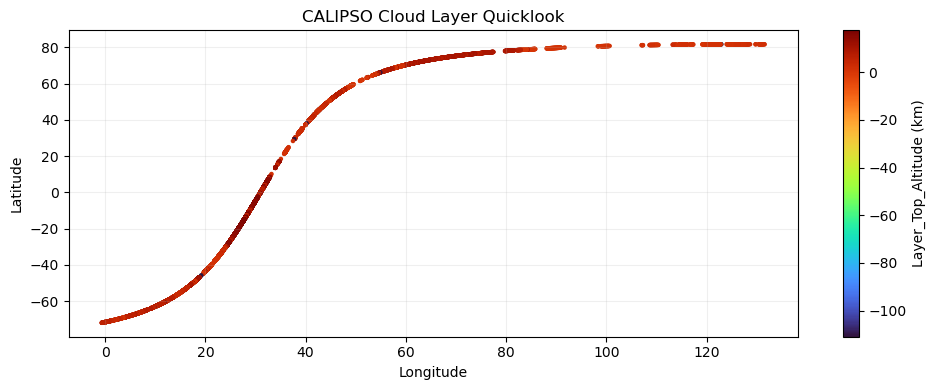

In [ ]:
# 鍙鍖?CALIPSO HDF锛堟寜绗竴灞備簯椤堕珮搴︾潃鑹诧級
# 鑻ユ湭瀹夎 pyhdf锛岃鍏堝湪鐜涓畨瑁咃細pip install pyhdf
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt

hdf_path = r"C:\Users\Cory Kong\Downloads\CAL_LID_L2_01kmCLay-Standard-V5-00.2023-02-17T00-45-48ZN.hdf"

hdf = SD(hdf_path, SDC.READ)
datasets = hdf.datasets()
print("鍙敤鍙橀噺鏁?", len(datasets))

lat = hdf.select('Latitude')[:].squeeze()
lon = hdf.select('Longitude')[:].squeeze()

# 甯歌浜戝眰椤堕珮搴﹀彉閲忓悕鍊欓€夛紙涓嶅悓浜у搧鐗堟湰鍙兘涓嶅悓锛塡n
alt_candidates = ['Layer_Top_Altitude', 'Layer_Top_Altitude_532', 'Layer_Base_Altitude']
alt_name = next((k for k in alt_candidates if k in datasets), None)
if alt_name is None:
    raise KeyError(f"鏈壘鍒伴珮搴﹀彉閲忋€傚彲鐢ㄥ彉閲忕ず渚? {list(datasets.keys())[:20]}")

alt = hdf.select(alt_name)[:]

# 濉厖鍊奸€氬父鏄緢灏忕殑璐熷€硷紝杩欓噷缁熶竴杞?NaN
alt = np.where(alt < -9000, np.nan, alt)

# 鍙栫涓€灞傦紙绗?0 鍒楋級鍋氱畝鍗曞彲瑙嗗寲
if alt.ndim == 2:
    alt_plot = alt[:, 0]
else:
    alt_plot = alt.squeeze()

plt.figure(figsize=(10, 4))
sc = plt.scatter(lon, lat, c=alt_plot, s=5, cmap='turbo')
plt.colorbar(sc, label=f'{alt_name} (km)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('CALIPSO Cloud Layer Quicklook')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
# 细节版可视化：轨迹 + 第一层云顶高度散点 + 多层云顶高度剖面
# 依赖：pip install pyhdf
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt

hdf_path = r"C:\Users\Cory Kong\Downloads\CAL_LID_L2_01kmCLay-Standard-V5-00.2023-02-17T00-45-48ZN.hdf"

hdf = SD(hdf_path, SDC.READ)
dsets = hdf.datasets()
print(f"数据集数量: {len(dsets)}")
print("前20个变量:", list(dsets.keys())[:20])

# 读取经纬度（通常是 [N,1]）
lat = hdf.select('Latitude')[:]
lon = hdf.select('Longitude')[:]
lat1d = np.asarray(lat).reshape(-1)
lon1d = np.asarray(lon).reshape(-1)

# 云层顶高度变量（不同版本变量名可能差异）
alt_candidates = ['Layer_Top_Altitude', 'Layer_Top_Altitude_532', 'Layer_Base_Altitude']
alt_name = next((k for k in alt_candidates if k in dsets), None)
if alt_name is None:
    raise KeyError(f"未找到高度变量，建议检查变量名。可用变量示例: {list(dsets.keys())[:40]}")

alt = np.asarray(hdf.select(alt_name)[:], dtype=float)
print(f"使用高度变量: {alt_name}, shape={alt.shape}")

# 处理填充值（CALIPSO 常见缺测填充值为极小负值）
alt[alt < -9000] = np.nan

# 如果是二维，通常为 [N, 层数]；如果不是，统一转成 [N,1]
if alt.ndim == 1:
    alt2d = alt.reshape(-1, 1)
elif alt.ndim == 2:
    alt2d = alt
else:
    # 少见情况，压成二维便于画图
    alt2d = alt.reshape(alt.shape[0], -1)

n_prof, n_layer = alt2d.shape
print(f"剖面点数: {n_prof}, 层数: {n_layer}")

# 第一层用于地图散点着色
first_layer = alt2d[:, 0]

fig = plt.figure(figsize=(14, 9))

# 1) 轨迹图
ax1 = plt.subplot(2, 2, 1)
ax1.plot(lon1d, lat1d, lw=0.7)
ax1.set_title('CALIPSO Orbit Track')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(alpha=0.25)

# 2) 第一层云顶高度地理散点
ax2 = plt.subplot(2, 2, 2)
sc = ax2.scatter(lon1d, lat1d, c=first_layer, s=5, cmap='turbo')
cb = plt.colorbar(sc, ax=ax2)
cb.set_label(f'{alt_name} layer-0 (km)')
ax2.set_title('Layer-0 Height Along Track')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(alpha=0.25)

# 3) 多层高度剖面热图（x=剖面序号, y=层号）
ax3 = plt.subplot(2, 1, 2)
img = ax3.imshow(
    alt2d.T,
    aspect='auto',
    origin='lower',
    cmap='turbo',
    interpolation='nearest'
)
cb2 = plt.colorbar(img, ax=ax3)
cb2.set_label(f'{alt_name} (km)')
ax3.set_title('Vertical Layer Height Curtain (by profile index)')
ax3.set_xlabel('Profile index')
ax3.set_ylabel('Layer index')

plt.tight_layout()
plt.show()

# 简单统计
print('第一层高度统计（km）:')
print('  min =', np.nanmin(first_layer))
print('  max =', np.nanmax(first_layer))
print('  mean=', np.nanmean(first_layer))


纬度范围: -71.94 to 81.69
经度范围: -0.68 to 138.32


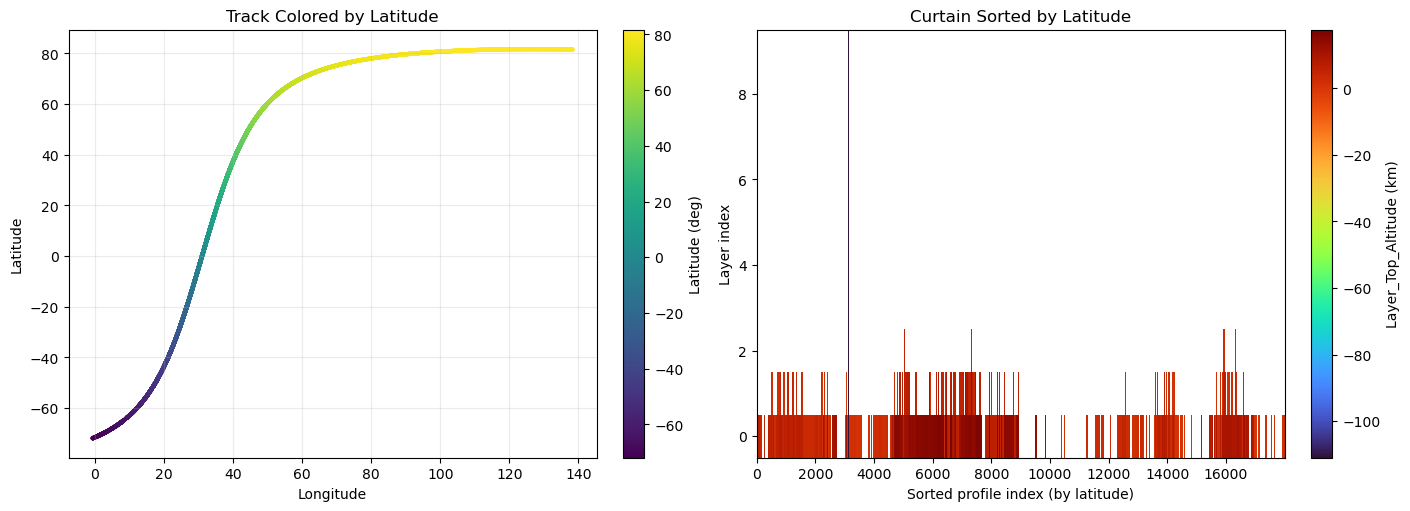

In [ ]:
# 按纬度排序的云层高度剖面图（更便于地理解释）
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt

hdf_path = r"C:\Users\Cory Kong\Downloads\CAL_LID_L2_01kmCLay-Standard-V5-00.2023-02-17T00-45-48ZN.hdf"

hdf = SD(hdf_path, SDC.READ)
dsets = hdf.datasets()

lat = np.asarray(hdf.select('Latitude')[:]).reshape(-1)
lon = np.asarray(hdf.select('Longitude')[:]).reshape(-1)

alt_candidates = ['Layer_Top_Altitude', 'Layer_Top_Altitude_532', 'Layer_Base_Altitude']
alt_name = next((k for k in alt_candidates if k in dsets), None)
if alt_name is None:
    raise KeyError(f"未找到高度变量。可用变量示例: {list(dsets.keys())[:40]}")

alt = np.asarray(hdf.select(alt_name)[:], dtype=float)
alt[alt < -9000] = np.nan

if alt.ndim == 1:
    alt2d = alt.reshape(-1, 1)
elif alt.ndim == 2:
    alt2d = alt
else:
    alt2d = alt.reshape(alt.shape[0], -1)

# 为避免维度不一致，统一截取到共同长度
n = min(len(lat), len(lon), alt2d.shape[0])
lat = lat[:n]
lon = lon[:n]
alt2d = alt2d[:n, :]

# 按纬度从低到高排序
order = np.argsort(lat)
lat_sorted = lat[order]
lon_sorted = lon[order]
alt_sorted = alt2d[order, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# 左图：轨迹（颜色表示纬度，便于和右图对应）
sc1 = axes[0].scatter(lon_sorted, lat_sorted, c=lat_sorted, s=4, cmap='viridis')
plt.colorbar(sc1, ax=axes[0], label='Latitude (deg)')
axes[0].set_title('Track Colored by Latitude')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(alpha=0.25)

# 右图：按纬度排序的多层高度 curtain
img = axes[1].imshow(
    alt_sorted.T,
    aspect='auto',
    origin='lower',
    cmap='turbo',
    interpolation='nearest'
)
plt.colorbar(img, ax=axes[1], label=f'{alt_name} (km)')
axes[1].set_title('Curtain Sorted by Latitude')
axes[1].set_xlabel('Sorted profile index (by latitude)')
axes[1].set_ylabel('Layer index')

# 给出纬度范围，帮助解释剖面覆盖区域
print(f'纬度范围: {np.nanmin(lat_sorted):.2f} to {np.nanmax(lat_sorted):.2f}')
print(f'经度范围: {np.nanmin(lon_sorted):.2f} to {np.nanmax(lon_sorted):.2f}')

plt.show()


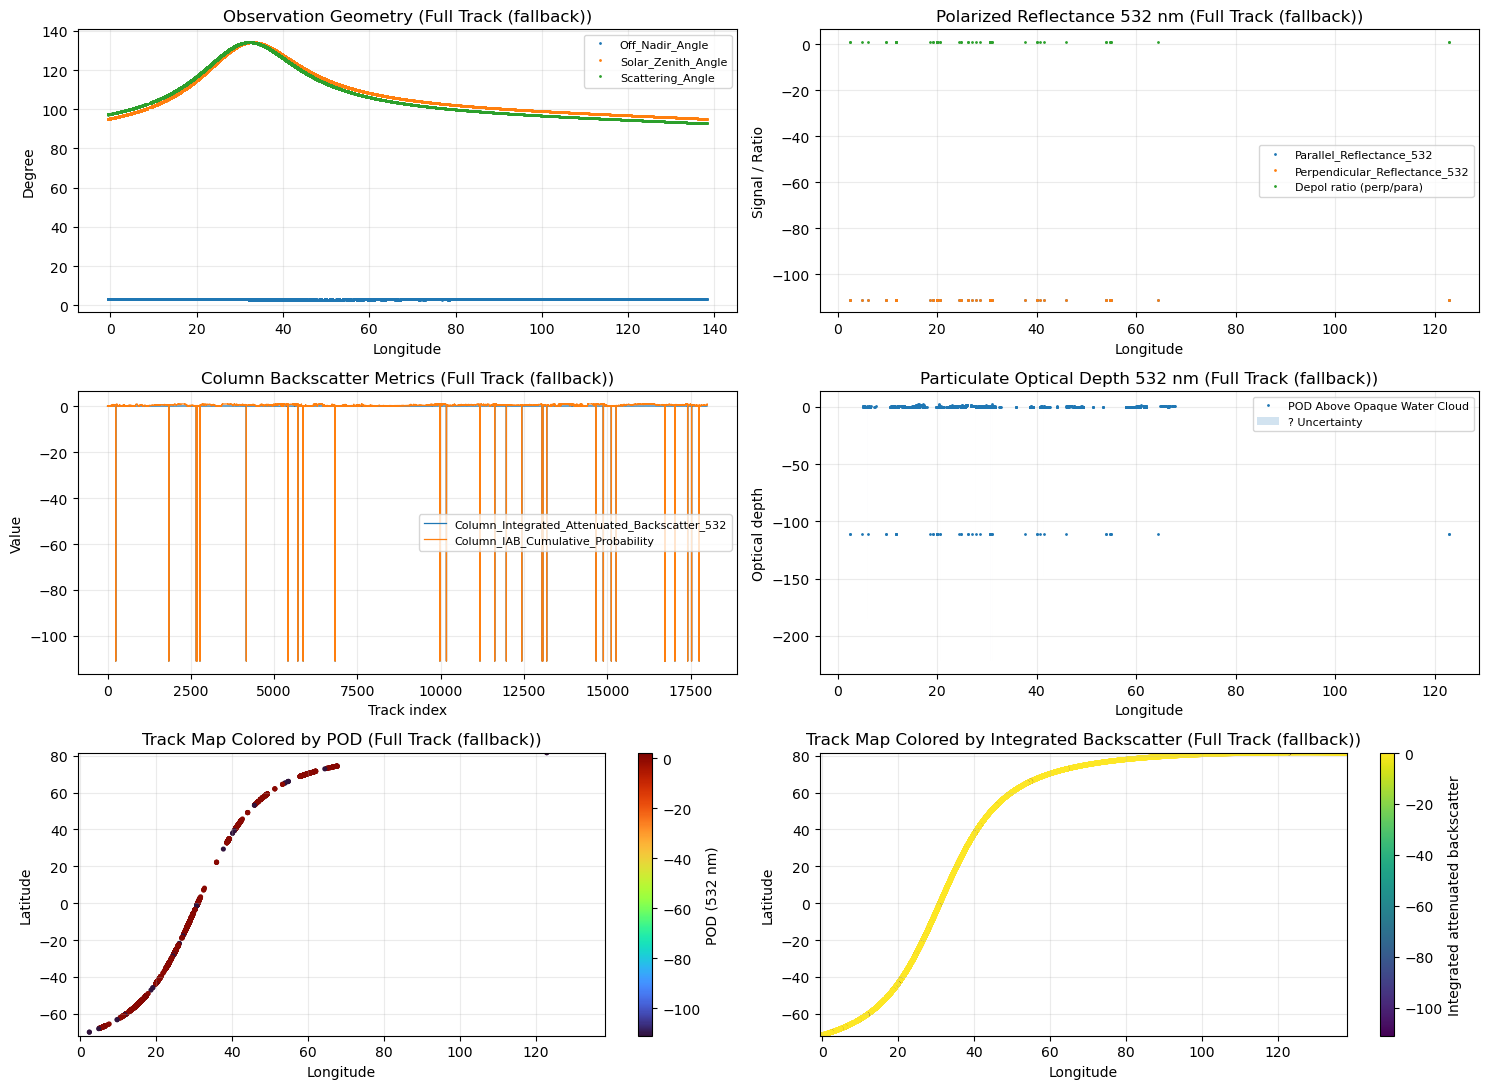

Requested East Asia box: lon[100.0, 150.0], lat[15.0, 55.0]
Original track extent: lon[-0.68, 138.32], lat[-71.94, 81.69]
Points plotted: 18000
Variable stats (NaN ignored):
  Off_Nadir_Angle: n=18000, min=2.963, max=3.005, mean=2.982
  Solar_Zenith_Angle: n=18000, min=95.02, max=134.2, mean=119.3
  Scattering_Angle: n=18000, min=92.75, max=134.2, mean=119.2
  Parallel_Column_Reflectance_532: n=52, min=-111, max=-111, mean=-111
  Perpendicular_Column_Reflectance_532: n=52, min=-111, max=-111, mean=-111
  Column_Integrated_Attenuated_Backscatter_532: n=18000, min=-111, max=0.1417, mean=-0.2888
  Column_IAB_Cumulative_Probability: n=18000, min=-111, max=0.9929, mean=0.1468
  Column_Particulate_Optical_Depth_Above_Opaque_Water_Cloud_532: n=3344, min=-111, max=2.286, mean=-1.604
  Column_Particulate_Optical_Depth_Above_Opaque_Water_Cloud_Uncertainty_532: n=3344, min=-111, max=0.3416, mean=-1.647


In [1]:
# Meaningful CALIPSO variables visualization (East Asia focus, ASCII-only)
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt

hdf_path = r"C:\Users\Cory Kong\Downloads\CAL_LID_L2_01kmCLay-Standard-V5-00.2023-02-17T00-45-48ZN.hdf"
hdf = SD(hdf_path, SDC.READ)
dsets = hdf.datasets()

# East Asia box (edit if needed)
LON_MIN, LON_MAX = 100.0, 150.0
LAT_MIN, LAT_MAX = 15.0, 55.0

def read_1d(name):
    if name not in dsets:
        return None
    arr = np.asarray(hdf.select(name)[:], dtype=float)
    if arr.ndim == 1:
        out = arr
    elif arr.ndim >= 2:
        out = arr[:, 0]
    else:
        out = arr.reshape(-1)
    out[(out < -9e3) | (out > 9e9)] = np.nan
    return out

lat = read_1d('Latitude')
lon = read_1d('Longitude')

vars_use = {
    'off_nadir': 'Off_Nadir_Angle',
    'solar_zenith': 'Solar_Zenith_Angle',
    'scattering': 'Scattering_Angle',
    'para_ref': 'Parallel_Column_Reflectance_532',
    'perp_ref': 'Perpendicular_Column_Reflectance_532',
    'iab532': 'Column_Integrated_Attenuated_Backscatter_532',
    'iab_prob': 'Column_IAB_Cumulative_Probability',
    'pod': 'Column_Particulate_Optical_Depth_Above_Opaque_Water_Cloud_532',
    'pod_unc': 'Column_Particulate_Optical_Depth_Above_Opaque_Water_Cloud_Uncertainty_532',
}
data = {k: read_1d(v) for k, v in vars_use.items()}

lengths = [len(x) for x in [lat, lon] + [v for v in data.values() if v is not None] if x is not None]
if not lengths:
    raise RuntimeError('No readable variables found in this file.')
n = min(lengths)
lat, lon = lat[:n], lon[:n]
for k in list(data.keys()):
    if data[k] is not None:
        data[k] = data[k][:n]

# Geographic mask for East Asia
mask_ea = (
    np.isfinite(lat) & np.isfinite(lon) &
    (lon >= LON_MIN) & (lon <= LON_MAX) &
    (lat >= LAT_MIN) & (lat <= LAT_MAX)
)

if mask_ea.sum() == 0:
    print('Warning: no track points inside East Asia box. Fallback to full-track plotting.')
    mask = np.isfinite(lat) & np.isfinite(lon)
    map_xlim = (np.nanmin(lon), np.nanmax(lon))
    map_ylim = (np.nanmin(lat), np.nanmax(lat))
    region_label = 'Full Track (fallback)'
else:
    mask = mask_ea
    map_xlim = (LON_MIN, LON_MAX)
    map_ylim = (LAT_MIN, LAT_MAX)
    region_label = 'East Asia'

lat = lat[mask]
lon = lon[mask]
for k in list(data.keys()):
    if data[k] is not None:
        data[k] = data[k][mask]

track_idx = np.arange(len(lat))

fig = plt.figure(figsize=(15, 11))

# 1) Observation geometry vs longitude
ax1 = plt.subplot(3, 2, 1)
if data['off_nadir'] is not None:
    ax1.plot(lon, data['off_nadir'], '.', ms=2, label='Off_Nadir_Angle')
if data['solar_zenith'] is not None:
    ax1.plot(lon, data['solar_zenith'], '.', ms=2, label='Solar_Zenith_Angle')
if data['scattering'] is not None:
    ax1.plot(lon, data['scattering'], '.', ms=2, label='Scattering_Angle')
ax1.set_title(f'Observation Geometry ({region_label})')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Degree')
ax1.grid(alpha=0.25)
ax1.legend(fontsize=8)

# 2) Polarized reflectance and depolarization ratio
ax2 = plt.subplot(3, 2, 2)
para = data['para_ref']
perp = data['perp_ref']
if para is not None:
    ax2.plot(lon, para, '.', ms=2, label='Parallel_Reflectance_532')
if perp is not None:
    ax2.plot(lon, perp, '.', ms=2, label='Perpendicular_Reflectance_532')
if (para is not None) and (perp is not None):
    depol = perp / (para + 1e-8)
    ax2.plot(lon, depol, '.', ms=2, label='Depol ratio (perp/para)')
ax2.set_title(f'Polarized Reflectance 532 nm ({region_label})')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Signal / Ratio')
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

# 3) Column backscatter metrics vs track index
ax3 = plt.subplot(3, 2, 3)
if data['iab532'] is not None:
    ax3.plot(track_idx, data['iab532'], lw=0.9, label='Column_Integrated_Attenuated_Backscatter_532')
if data['iab_prob'] is not None:
    ax3.plot(track_idx, data['iab_prob'], lw=0.9, label='Column_IAB_Cumulative_Probability')
ax3.set_title(f'Column Backscatter Metrics ({region_label})')
ax3.set_xlabel('Track index')
ax3.set_ylabel('Value')
ax3.grid(alpha=0.25)
ax3.legend(fontsize=8)

# 4) POD with uncertainty
ax4 = plt.subplot(3, 2, 4)
pod = data['pod']
pod_unc = data['pod_unc']
if pod is not None:
    ax4.plot(lon, pod, '.', ms=2, label='POD Above Opaque Water Cloud')
if (pod is not None) and (pod_unc is not None):
    order = np.argsort(lon)
    x = lon[order]
    y = pod[order]
    u = pod_unc[order]
    ax4.fill_between(x, y - u, y + u, alpha=0.2, label='? Uncertainty')
ax4.set_title(f'Particulate Optical Depth 532 nm ({region_label})')
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Optical depth')
ax4.grid(alpha=0.25)
ax4.legend(fontsize=8)

# 5) Track map colored by POD
ax5 = plt.subplot(3, 2, 5)
if pod is not None:
    sc = ax5.scatter(lon, lat, c=pod, s=7, cmap='turbo')
    plt.colorbar(sc, ax=ax5, label='POD (532 nm)')
else:
    ax5.scatter(lon, lat, s=3)
ax5.set_title(f'Track Map Colored by POD ({region_label})')
ax5.set_xlabel('Longitude')
ax5.set_ylabel('Latitude')
ax5.set_xlim(*map_xlim)
ax5.set_ylim(*map_ylim)
ax5.grid(alpha=0.25)

# 6) Track map colored by integrated backscatter
ax6 = plt.subplot(3, 2, 6)
iab = data['iab532']
if iab is not None:
    sc2 = ax6.scatter(lon, lat, c=iab, s=7, cmap='viridis')
    plt.colorbar(sc2, ax=ax6, label='Integrated attenuated backscatter')
else:
    ax6.scatter(lon, lat, s=3)
ax6.set_title(f'Track Map Colored by Integrated Backscatter ({region_label})')
ax6.set_xlabel('Longitude')
ax6.set_ylabel('Latitude')
ax6.set_xlim(*map_xlim)
ax6.set_ylim(*map_ylim)
ax6.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Requested East Asia box: lon[{LON_MIN}, {LON_MAX}], lat[{LAT_MIN}, {LAT_MAX}]')
print(f'Original track extent: lon[{np.nanmin(read_1d("Longitude")):.2f}, {np.nanmax(read_1d("Longitude")):.2f}], '
      f'lat[{np.nanmin(read_1d("Latitude")):.2f}, {np.nanmax(read_1d("Latitude")):.2f}]')
print(f'Points plotted: {len(lat)}')
print('Variable stats (NaN ignored):')
for k, arr in data.items():
    if arr is None:
        print(f'  {vars_use[k]}: not found')
    else:
        valid = np.isfinite(arr)
        if valid.sum() == 0:
            print(f'  {vars_use[k]}: all missing')
        else:
            print(f'  {vars_use[k]}: n={valid.sum()}, min={np.nanmin(arr):.4g}, max={np.nanmax(arr):.4g}, mean={np.nanmean(arr):.4g}')
